# Filtro de Kalman aplicado al Modelo de Nelson-Siegel Dinámico
### Una guía paso a paso con rendimientos de Tesoros de Estados Unidos

---

## ¿Qué vamos a hacer?

Vamos a modelar la **curva de rendimientos** (yield curve) de los bonos del Tesoro de EE.UU. usando el modelo de **Nelson-Siegel Dinámico**.

La idea es simple: en lugar de quedarnos con una foto estática de la curva, queremos seguirla **en el tiempo** — ver cómo evoluciona cada semana. Para eso usamos el **Filtro de Kalman**, un algoritmo que va actualizando sus estimaciones a medida que llegan nuevos datos.


In [154]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec

# Estilo visual limpio
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.4
plt.rcParams['font.family'] = 'DejaVu Sans'

print('Librerías cargadas correctamente ✓')

Librerías cargadas correctamente ✓


---

## Parte 1 — Los datos

Cargamos rendimientos semanales de bonos del Tesoro de EE.UU. para distintos plazos:
**1, 2, 3, 5, 7, 10, 20 y 30 años**.

Cada fila es una semana. Cada columna es una tasa de rendimiento (en %).

In [155]:
# Cargamos el CSV
df = pd.read_csv(r'C:\Users\ADMON\Documents\Universidad\Proyecto KMJ\codigo\Filtro de Kalman\muestra_rend_EEUU.csv', parse_dates=['Date'], index_col='Date')

# Plazos en años (los vencimientos de los tesoros)
plazos = np.array([1, 2, 3, 5, 7, 10, 20, 30])

print(f'Fechas: {df.index[0].date()} → {df.index[-1].date()}')
print(f'Observaciones: {len(df)}')
print(f'Plazos (años): {plazos}')
print()
df.head()

Fechas: 2025-05-09 → 2026-03-05
Observaciones: 30
Plazos (años): [ 1  2  3  5  7 10 20 30]



,SVENY01,SVENY02,SVENY03,SVENY05,SVENY07,SVENY10,SVENY20,SVENY30
Date,,,,,,,,
2025-05-09,4.0236,3.8663,3.8465,3.9746,4.1665,4.4417,4.9540,5.0166
2025-05-20,4.0856,3.9479,3.9242,4.0448,4.2458,4.5481,5.0942,5.0957
2025-05-30,4.0966,3.8950,3.8452,3.9559,4.1624,4.4754,5.0526,5.0801
2025-06-10,4.1253,3.9844,3.9548,4.0589,4.2424,4.5226,5.0495,5.0796
2025-06-20,4.0646,3.8785,3.8340,3.9402,4.1360,4.4343,5.0043,5.0616


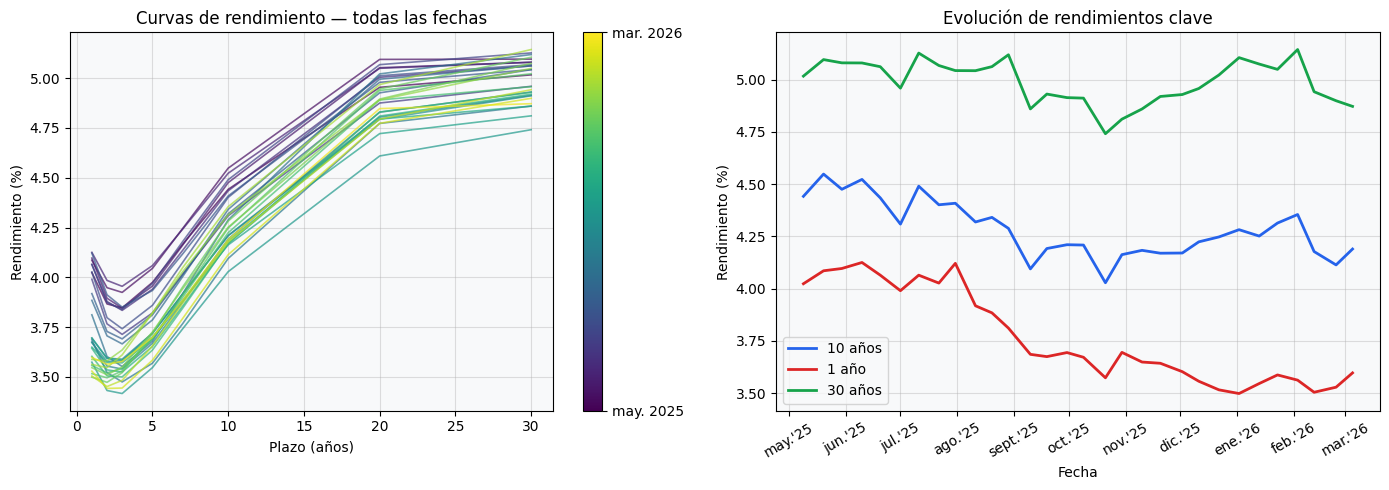

In [156]:
# Visualizamos la curva de rendimientos en cada fecha disponible
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: todas las curvas juntas
ax1 = axes[0]
cmap = plt.cm.viridis
n = len(df)
for i, (fecha, fila) in enumerate(df.iterrows()):
    ax1.plot(plazos, fila.values, color=cmap(i / n), alpha=0.7, linewidth=1.2)

# Barra de color para las fechas
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, n-1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax1)
fechas_str = [df.index[0].strftime('%b %Y'), df.index[-1].strftime('%b %Y')]
cbar.set_ticks([0, n-1])
cbar.set_ticklabels(fechas_str)
ax1.set_xlabel('Plazo (años)')
ax1.set_ylabel('Rendimiento (%)')
ax1.set_title('Curvas de rendimiento — todas las fechas')

# Panel derecho: evolución del rendimiento a 10 años
ax2 = axes[1]
ax2.plot(df.index, df['SVENY10'], color='#2563eb', linewidth=2, label='10 años')
ax2.plot(df.index, df['SVENY01'], color='#dc2626', linewidth=2, label='1 año')
ax2.plot(df.index, df['SVENY30'], color='#16a34a', linewidth=2, label='30 años')
ax2.set_xlabel('Fecha')
ax2.set_ylabel('Rendimiento (%)')
ax2.set_title('Evolución de rendimientos clave')
ax2.legend()
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b\'%y'))
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

---

## Parte 2 — El modelo de Nelson-Siegel

El modelo de Nelson-Siegel describe la curva de rendimientos con **3 factores** y una constante λ (lambda):

$$y(\tau) = \beta_1 + \beta_2 \cdot \frac{1 - e^{-\lambda\tau}}{\lambda\tau} + \beta_3 \cdot \left[\frac{1 - e^{-\lambda\tau}}{\lambda\tau} - e^{-\lambda\tau}\right]$$

Donde τ (tau) es el plazo en años y:

| Factor | Símbolo | Interpretación |
|--------|---------|----------------|
| Nivel  | β₁      | Afecta igual a todos los plazos. Es el rendimiento de muy largo plazo. |
| Pendiente | β₂   | Diferencia entre corto y largo plazo. Si es negativo → curva invertida. |
| Curvatura | β₃   | La "joroba" de la curva. Captura el plazo medio. |

**λ** controla a qué plazo aparece esa joroba. Lo fijaremos en λ = 0.0609 (valor clásico de Diebold & Li).

### La clave del modelo DINÁMICO

En la versión estática, β₁, β₂ y β₃ son fijos. En la versión **dinámica**, estos factores cambian en cada período de tiempo. Eso es exactamente lo que el Filtro de Kalman va a rastrear.

In [157]:
# Definimos el parámetro lambda y los plazos
lam = 0.45  # Diebold & Li (2006)

def cargar_factores_NS(tau, lam):
    """
    Calcula las tres cargas (loadings) del modelo Nelson-Siegel
    para un plazo tau dado.
    
    Retorna un vector [carga_nivel, carga_pendiente, carga_curvatura]
    """
    exp_term = np.exp(-lam * tau)
    decay    = (1 - exp_term) / (lam * tau)  # Factor que decae

    carga_nivel      = 1.0
    carga_pendiente  = decay
    carga_curvatura  = decay - exp_term

    return np.array([carga_nivel, carga_pendiente, carga_curvatura])


def matriz_carga_C(plazos, lam):
    """
    Construye la MATRIZ DE CARGA C.
    Cada fila corresponde a un plazo, y tiene 3 columnas:
    [carga_nivel, carga_pendiente, carga_curvatura]
    
    Esta matriz C conecta los factores (estado) con los rendimientos (observaciones).
    """
    C = np.array([cargar_factores_NS(tau, lam) for tau in plazos])
    return C


# Construimos C con nuestros 8 plazos
C = matriz_carga_C(plazos, lam)

print('Matriz de carga C (8 plazos × 3 factores):')
print(f'{"Plazo":>8} | {"Nivel":>8} | {"Pendiente":>10} | {"Curvatura":>10}')
print('-' * 46)
for i, tau in enumerate(plazos):
    print(f'{tau:>8} | {C[i,0]:>8.4f} | {C[i,1]:>10.4f} | {C[i,2]:>10.4f}')

Matriz de carga C (8 plazos × 3 factores):
   Plazo |    Nivel |  Pendiente |  Curvatura
----------------------------------------------
       1 |   1.0000 |     0.8053 |     0.1676
       2 |   1.0000 |     0.6594 |     0.2528
       3 |   1.0000 |     0.5487 |     0.2895
       5 |   1.0000 |     0.3976 |     0.2922
       7 |   1.0000 |     0.3039 |     0.2610
      10 |   1.0000 |     0.2198 |     0.2086
      20 |   1.0000 |     0.1111 |     0.1110
      30 |   1.0000 |     0.0741 |     0.0741


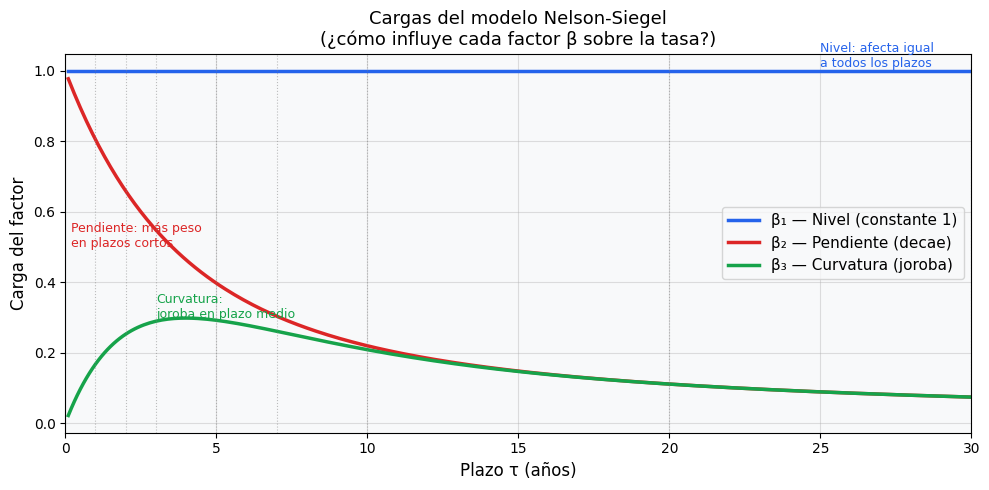

In [158]:
# Visualizamos las cargas para entender qué captura cada factor
tau_fino = np.linspace(0.1, 30, 300)  # Plazos continuos para graficar
C_fino = matriz_carga_C(tau_fino, lam)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(tau_fino, C_fino[:, 0], color='#2563eb', linewidth=2.5, label='β₁ — Nivel (constante 1)')
ax.plot(tau_fino, C_fino[:, 1], color='#dc2626', linewidth=2.5, label='β₂ — Pendiente (decae)')
ax.plot(tau_fino, C_fino[:, 2], color='#16a34a', linewidth=2.5, label='β₃ — Curvatura (joroba)')

# Marcamos nuestros plazos reales
for tau in plazos:
    ax.axvline(tau, color='gray', linestyle=':', alpha=0.5, linewidth=0.8)

ax.set_xlabel('Plazo τ (años)', fontsize=12)
ax.set_ylabel('Carga del factor', fontsize=12)
ax.set_title('Cargas del modelo Nelson-Siegel\n(¿cómo influye cada factor β sobre la tasa?)', fontsize=13)
ax.legend(fontsize=11)
ax.set_xlim(0, 30)

# Anotaciones
ax.annotate('Nivel: afecta igual\na todos los plazos', xy=(25, 1.01), fontsize=9, color='#2563eb')
ax.annotate('Pendiente: más peso\nen plazos cortos', xy=(0.2, 0.50), fontsize=9, color='#dc2626')
ax.annotate('Curvatura:\njoroba en plazo medio', xy=(3, 0.30), fontsize=9, color='#16a34a')

plt.tight_layout()
plt.show()

---

## Parte 3 — La estructura de espacio de estados

Para usar el Filtro de Kalman necesitamos escribir el modelo en forma de **espacio de estados**. Esto tiene dos ecuaciones:

### Ecuación de estado (transición)
Describe cómo evolucionan los factores β de un período al siguiente:

$$\hat{x}_k^- = A\hat{x}_{k-1} + Bu_k$$

En Nelson-Siegel dinámico asumimos que los factores siguen un **proceso AR(1)** (caminata aleatoria por simplicidad):
- **A** = I (la identidad) — cada factor persiste de un período al siguiente
- **B u_k** = 0 — no hay entradas externas
- El ruido de proceso tiene covarianza **Q**

### Ecuación de observación
Conecta los factores con los rendimientos observados:

$$y_k = C\hat{x}_k + \varepsilon_k$$

- **y_k** = vector de 8 rendimientos observados en el período k
- **C** = matriz de cargas NS (la que construimos arriba)
- **R** = covarianza del ruido de medición

Gráficamente:

```
   Estado oculto         Observación
  ┌──────────────┐      ┌─────────────────────────┐
  │  [β₁]        │      │  y(1yr)   = C[0,:] x β  │
  │  [β₂]  ───►  │  C   │  y(2yr)   = C[1,:] x β  │
  │  [β₃]        │      │  ...                    │
  └──────────────┘      │  y(30yr)  = C[7,:] x β  │
   (3 factores)         └─────────────────────────┘
                           (8 rendimientos)
```

In [169]:
# ─── PARÁMETROS DEL MODELO ───────────────────────────────────────────────────

n_estados = 3   # β₁, β₂, β₃
n_obs     = 8   # 8 plazos

# Matriz de transición A — asumimos caminata aleatoria (identidad)
A = np.eye(n_estados)

# Covarianza del ruido de PROCESO Q
# Refleja cuánto pueden cambiar los factores entre períodos
# Valores pequeños → factores más suaves
q_nivel     = 0.0005
q_pendiente = 0.0005
q_curvatura = 0.0005
Q = np.diag([q_nivel, q_pendiente, q_curvatura])

# Covarianza del ruido de MEDICIÓN R
# Refleja cuánto nos "equivocamos" al medir los rendimientos
# Lo asumimos igual para todos los plazos (ruido blanco uniforme)
sigma_r = 0.01   # ~1 punto base de error de medición
R = (sigma_r ** 2) * np.eye(n_obs)

print('Dimensiones del sistema:')
print(f'  Estado (x): {n_estados} factores  →  β₁ (nivel), β₂ (pendiente), β₃ (curvatura)')
print(f'  Observaciones (y): {n_obs} rendimientos')
print(f'  Matriz A: {A.shape}  (identidad → caminata aleatoria)')
print(f'  Matriz C: {C.shape}  (cargas Nelson-Siegel)')
print(f'  Matriz Q: {Q.shape}  (ruido de proceso)')
print(f'  Matriz R: {R.shape}  (ruido de medición)')
Q

Dimensiones del sistema:
  Estado (x): 3 factores  →  β₁ (nivel), β₂ (pendiente), β₃ (curvatura)
  Observaciones (y): 8 rendimientos
  Matriz A: (3, 3)  (identidad → caminata aleatoria)
  Matriz C: (8, 3)  (cargas Nelson-Siegel)
  Matriz Q: (3, 3)  (ruido de proceso)
  Matriz R: (8, 8)  (ruido de medición)


array([[0.0005, 0.    , 0.    ],
       [0.    , 0.0005, 0.    ],
       [0.    , 0.    , 0.0005]])

---

## Parte 4 — El Filtro de Kalman paso a paso

El filtro de Kalman tiene **dos pasos** que se repiten en cada período:

---

### 🔮 PASO 1 — Predicción

Con lo que sabemos al final del período k-1, **proyectamos** hacia el período k:

$$\hat{x}_k^- = A\hat{x}_{k-1}$$

$$P_k^- = AP_{k-1}A^T + Q$$

- $\hat{x}_k^-$ es nuestra **mejor estimación antes de ver los datos nuevos** (el símbolo ⁻ significa "a priori")
- $P_k^-$ es la **incertidumbre** de esa estimación
- Al sumar Q, reconocemos que los factores pueden haberse movido un poco

---

### 🔄 PASO 2 — Actualización

Ahora llegan los rendimientos nuevos $y_k$. Los comparamos con lo que predijimos y **corregimos**:

$$K_k = \frac{P_k^- C^T}{CP_k^- C^T + R}$$

$$\hat{x}_k = \hat{x}_k^- + K_k(y_k - C\hat{x}_k^-)$$

$$P_k = (I - K_kC)P_k^-$$

- $K_k$ es la **ganancia de Kalman**: decide cuánto confiamos en el nuevo dato vs. en nuestra predicción
- $(y_k - C\hat{x}_k^-)$ es el **residuo** ("innovación"): la diferencia entre lo observado y lo predicho
- Si $K_k$ es grande → confiamos más en los datos nuevos
- Si $K_k$ es pequeño → confiamos más en la predicción

---

**La intuición:** el filtro es un promedio ponderado entre "lo que yo esperaba" y "lo que realmente pasó".

In [160]:
# ─── FUNCIÓN PRINCIPAL: FILTRO DE KALMAN ────────────────────────────────────

def filtro_kalman(Y, A, C, Q, R, x0, P0):
    """
    Implementación del Filtro de Kalman para el modelo de espacio de estados:

        Estado:      x_k = A * x_{k-1} + ruido(Q)
        Observación: y_k = C * x_k     + ruido(R)

    Parámetros:
    -----------
    Y  : matriz T × n_obs   → observaciones (rendimientos)
    A  : n_estados × n_estados → matriz de transición
    C  : n_obs × n_estados     → matriz de observación (cargas NS)
    Q  : n_estados × n_estados → covarianza ruido de proceso
    R  : n_obs × n_obs         → covarianza ruido de medición
    x0 : vector n_estados      → estado inicial
    P0 : n_estados × n_estados → incertidumbre inicial

    Retorna:
    --------
    X_filtrado  : T × n_estados  → factores estimados (β₁, β₂, β₃)
    P_filtrado  : lista de T matrices de covarianza
    X_predicho  : T × n_estados  → factores antes de actualizar
    residuos    : T × n_obs      → innovaciones (y_obs - y_pred)
    ganancias_K : lista de T matrices de ganancia
    """
    T        = Y.shape[0]
    n_est    = A.shape[0]

    # Reservamos memoria para guardar resultados
    X_filtrado = np.zeros((T, n_est))
    X_predicho = np.zeros((T, n_est))
    P_filtrado = [None] * T
    residuos   = np.zeros((T, Y.shape[1]))
    ganancias_K= [None] * T

    # Estado inicial
    x = x0.copy()
    P = P0.copy()

    I = np.eye(n_est)  # Matriz identidad

    for k in range(T):
        # ── PASO 1: PREDICCIÓN ─────────────────────────────────────────────
        # Proyectamos el estado
        x_pred = A @ x                         # x̂ₖ⁻ = A x̂ₖ₋₁
        P_pred = A @ P @ A.T + Q               # Pₖ⁻ = A Pₖ₋₁ Aᵀ + Q

        X_predicho[k] = x_pred

        # ── PASO 2: ACTUALIZACIÓN ──────────────────────────────────────────
        y_k = Y[k]                             # Rendimientos observados

        # Residuo (innovación): diferencia entre lo observado y lo predicho
        innovacion = y_k - C @ x_pred          # yₖ - C x̂ₖ⁻

        # Covarianza de la innovación
        S = C @ P_pred @ C.T + R               # S = C Pₖ⁻ Cᵀ + R

        # Ganancia de Kalman: decide cuánto corregimos
        K = P_pred @ C.T @ np.linalg.inv(S)   # Kₖ = Pₖ⁻ Cᵀ / S

        # Actualizamos el estado con el nuevo dato
        x = x_pred + K @ innovacion            # x̂ₖ = x̂ₖ⁻ + Kₖ(yₖ - C x̂ₖ⁻)

        # Actualizamos la incertidumbre
        P = (I - K @ C) @ P_pred               # Pₖ = (I - KₖC) Pₖ⁻

        # Guardamos resultados de este período
        X_filtrado[k]  = x
        P_filtrado[k]  = P
        residuos[k]    = innovacion
        ganancias_K[k] = K

    return X_filtrado, P_filtrado, X_predicho, residuos, ganancias_K


print('Función del Filtro de Kalman definida ✓')

Función del Filtro de Kalman definida ✓


---

## Parte 5 — Condiciones iniciales

Para arrancar el filtro necesitamos dos cosas:

1. **x₀** — una estimación inicial de los factores β
2. **P₀** — cuánta incertidumbre tenemos sobre esa estimación inicial

Usaremos la primera curva observada para estimar β₀ por mínimos cuadrados ordinarios (OLS), y arrancaremos con una incertidumbre alta (P₀ grande) para que el filtro se ajuste rápido al principio.

In [161]:
# ─── CONDICIONES INICIALES ───────────────────────────────────────────────────

# Convertimos los datos a numpy (T x 8)
Y = df.values   # T filas (fechas) × 8 columnas (plazos)

# Estimamos β₀ usando la PRIMERA observación por OLS:
# y₁ ≈ C β  →  β̂ = (CᵀC)⁻¹ Cᵀ y₁
y_primera = Y[0]                                    # Rendimientos del primer día
x0 = np.linalg.lstsq(C, y_primera, rcond=None)[0]  # OLS: resuelve C β = y

# Incertidumbre inicial alta (no sabemos mucho)
P0 = 10 * np.eye(n_estados)

print('Condiciones iniciales:')
print(f'  β₁ inicial (nivel):      {x0[0]:.4f}%')
print(f'  β₂ inicial (pendiente):  {x0[1]:.4f}%')
print(f'  β₃ inicial (curvatura):  {x0[2]:.4f}%')
print()

# Verificación: ¿qué tan bien se ajusta esta estimación inicial?
y_ajustada = C @ x0
print('Ajuste inicial de la curva (primeros 4 plazos):')
print(f'{"Plazo":>8} | {"Observado":>10} | {"Estimado":>10} | {"Error":>8}')
print('-' * 44)
for i, tau in enumerate(plazos[:4]):
    error = y_primera[i] - y_ajustada[i]
    print(f'{tau:>8} | {y_primera[i]:>10.4f} | {y_ajustada[i]:>10.4f} | {error:>8.4f}')

Condiciones iniciales:
  β₁ inicial (nivel):      5.3953%
  β₂ inicial (pendiente):  -0.9646%
  β₃ inicial (curvatura):  -3.5391%

Ajuste inicial de la curva (primeros 4 plazos):
   Plazo |  Observado |   Estimado |    Error
--------------------------------------------
       1 |     4.0236 |     4.0253 |  -0.0017
       2 |     3.8663 |     3.8646 |   0.0017
       3 |     3.8465 |     3.8416 |   0.0049
       5 |     3.9746 |     3.9777 |  -0.0031


---

## Parte 6 — Ejecutamos el Filtro de Kalman

Ahora sí: corremos el filtro sobre todas las observaciones.

In [162]:
# ─── EJECUTAMOS EL FILTRO ────────────────────────────────────────────────────

X_filtrado, P_filtrado, X_predicho, residuos, ganancias_K = filtro_kalman(
    Y   = Y,
    A   = A,
    C   = C,
    Q   = Q,
    R   = R,
    x0  = x0,
    P0  = P0
)

T = len(df)

print(f'Filtro ejecutado sobre {T} períodos ✓')
print()
print('Resumen de los factores estimados:')
print(f'{"Fecha":>12} | {"β₁ (nivel)":>12} | {"β₂ (pend.)":>12} | {"β₃ (curv.)":>12}')
print('-' * 58)
for i, fecha in enumerate(df.index):
    print(f'{str(fecha.date()):>12} | {X_filtrado[i,0]:>12.4f} | {X_filtrado[i,1]:>12.4f} | {X_filtrado[i,2]:>12.4f}')

Filtro ejecutado sobre 30 períodos ✓

Resumen de los factores estimados:
       Fecha |   β₁ (nivel) |   β₂ (pend.) |   β₃ (curv.)
----------------------------------------------------------
  2025-05-09 |       5.3953 |      -0.9646 |      -3.5391
  2025-05-20 |       5.4976 |      -0.9991 |      -3.5579
  2025-05-30 |       5.4801 |      -0.9677 |      -3.7727
  2025-06-10 |       5.4924 |      -0.9101 |      -3.6740
  2025-06-20 |       5.4463 |      -0.9344 |      -3.7967
  2025-07-01 |       5.3483 |      -0.8994 |      -3.9290
  2025-07-11 |       5.5233 |      -0.9762 |      -3.9602
  2025-07-22 |       5.4854 |      -0.9844 |      -4.1164
  2025-07-31 |       5.4689 |      -0.8299 |      -4.1014
  2025-08-11 |       5.4298 |      -0.9775 |      -4.1805
  2025-08-20 |       5.4838 |      -1.0751 |      -4.2731
  2025-08-29 |       5.5336 |      -1.2002 |      -4.5475
  2025-09-10 |       5.3362 |      -1.0811 |      -4.5486
  2025-09-19 |       5.3832 |      -1.1268 |      -4.404

---

## Parte 7 — Visualizando los factores estimados

Graficamos cómo evolucionaron β₁, β₂ y β₃ a lo largo del tiempo.

También mostramos las **bandas de incertidumbre** del filtro (±2 desviaciones estándar).

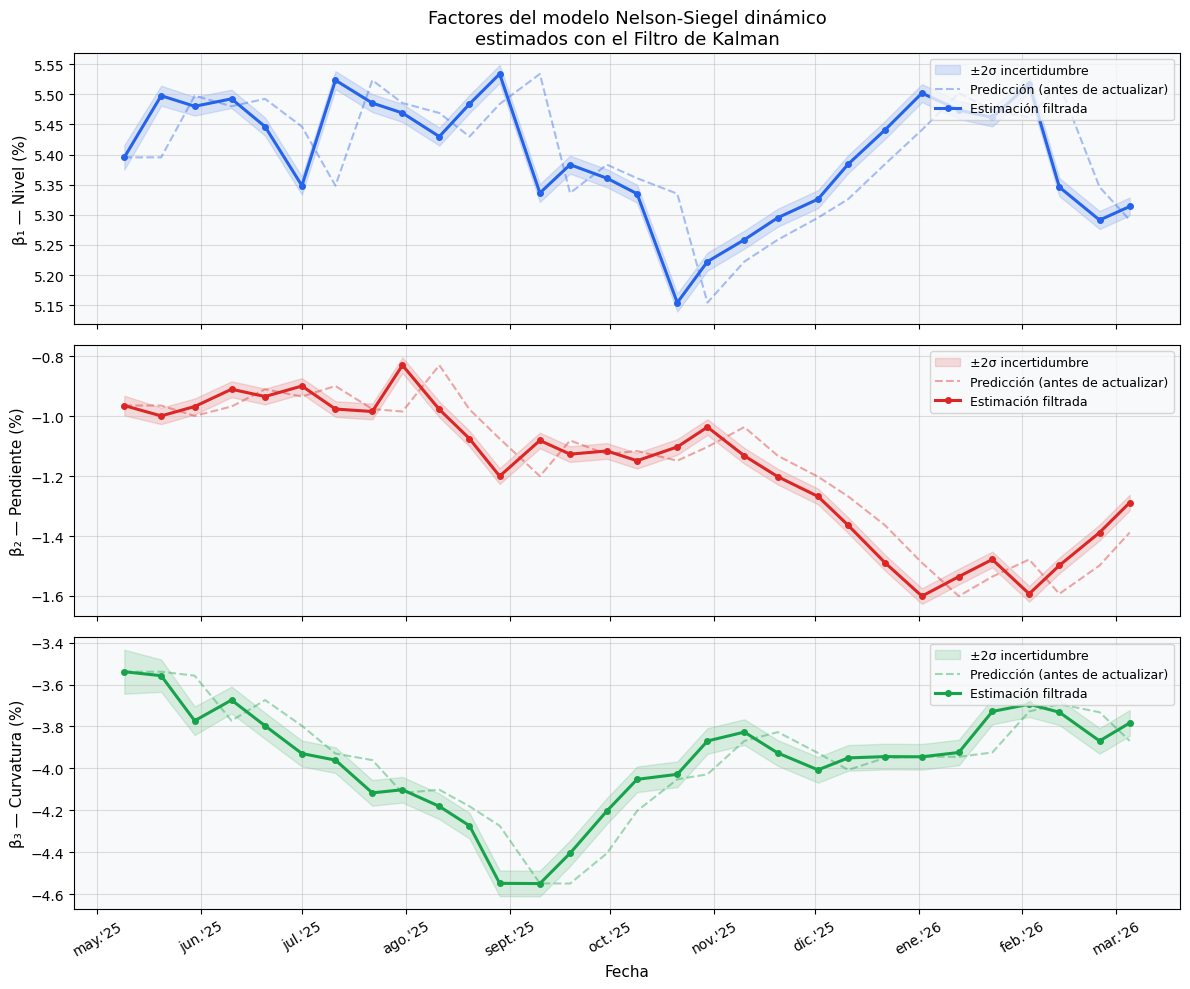

Interpretación rápida:
  β₁ promedio (nivel a largo plazo): 5.400%
  β₂ promedio (pendiente):           -1.172%
  β₃ promedio (curvatura):           -3.963%


In [163]:
# Extraemos las desviaciones estándar de cada factor (raíz de la diagonal de P)
stds = np.array([np.sqrt(np.diag(P_filtrado[k])) for k in range(T)])

fechas = df.index
nombres = ['β₁ — Nivel', 'β₂ — Pendiente', 'β₃ — Curvatura']
colores = ['#2563eb', '#dc2626', '#16a34a']

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

for i in range(3):
    ax = axes[i]
    factor    = X_filtrado[:, i]
    predicho  = X_predicho[:, i]
    std_i     = stds[:, i]

    # Banda de confianza ±2σ
    ax.fill_between(fechas,
                    factor - 2*std_i,
                    factor + 2*std_i,
                    alpha=0.15, color=colores[i], label='±2σ incertidumbre')

    # Factor predicho (antes de actualizar)
    ax.plot(fechas, predicho, '--', color=colores[i], alpha=0.4,
            linewidth=1.5, label='Predicción (antes de actualizar)')

    # Factor filtrado (después de actualizar con los datos)
    ax.plot(fechas, factor, '-o', color=colores[i], linewidth=2.2,
            markersize=4, label='Estimación filtrada')

    ax.set_ylabel(f'{nombres[i]} (%)', fontsize=11)
    ax.legend(fontsize=9, loc='upper right')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\'%y'))

axes[0].set_title('Factores del modelo Nelson-Siegel dinámico\nestimados con el Filtro de Kalman', fontsize=13)
axes[-1].set_xlabel('Fecha', fontsize=11)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print('Interpretación rápida:')
print(f'  β₁ promedio (nivel a largo plazo): {X_filtrado[:,0].mean():.3f}%')
print(f'  β₂ promedio (pendiente):           {X_filtrado[:,1].mean():.3f}%')
print(f'  β₃ promedio (curvatura):           {X_filtrado[:,2].mean():.3f}%')

---

## Parte 8 — ¿Qué tan bien ajusta la curva?

Comparamos la curva **observada** vs. la curva **estimada** por el filtro en cada período.

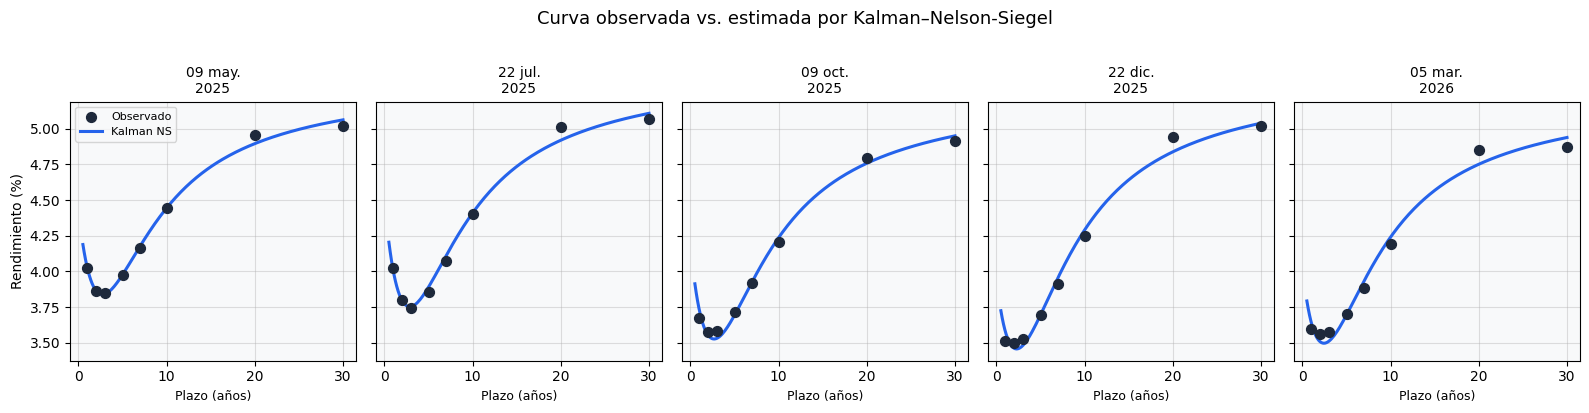

In [164]:
# Curvas estimadas: multiplicamos los factores filtrados por la matriz de carga C
Y_estimado = X_filtrado @ C.T    # Cada fila: rendimientos estimados en ese período

# ─── Gráfica: Curvas observadas vs. estimadas en momentos clave ──────────────
indices_muestra = [0, len(df)//4, len(df)//2, 3*len(df)//4, len(df)-1]

fig, axes = plt.subplots(1, len(indices_muestra), figsize=(16, 4), sharey=True)

tau_fino = np.linspace(0.5, 30, 200)
C_fino   = matriz_carga_C(tau_fino, lam)

for col, idx in enumerate(indices_muestra):
    ax = axes[col]
    fecha = df.index[idx]

    # Curva observada (puntos)
    ax.scatter(plazos, Y[idx], color='#1e293b', zorder=5, s=50, label='Observado')

    # Curva ajustada por el filtro (línea continua, usando C fino)
    curva_suave = C_fino @ X_filtrado[idx]
    ax.plot(tau_fino, curva_suave, color='#2563eb', linewidth=2.2, label='Kalman NS')

    ax.set_title(fecha.strftime('%d %b\n%Y'), fontsize=10)
    ax.set_xlabel('Plazo (años)', fontsize=9)
    if col == 0:
        ax.set_ylabel('Rendimiento (%)', fontsize=10)
        ax.legend(fontsize=8)

fig.suptitle('Curva observada vs. estimada por Kalman–Nelson-Siegel', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

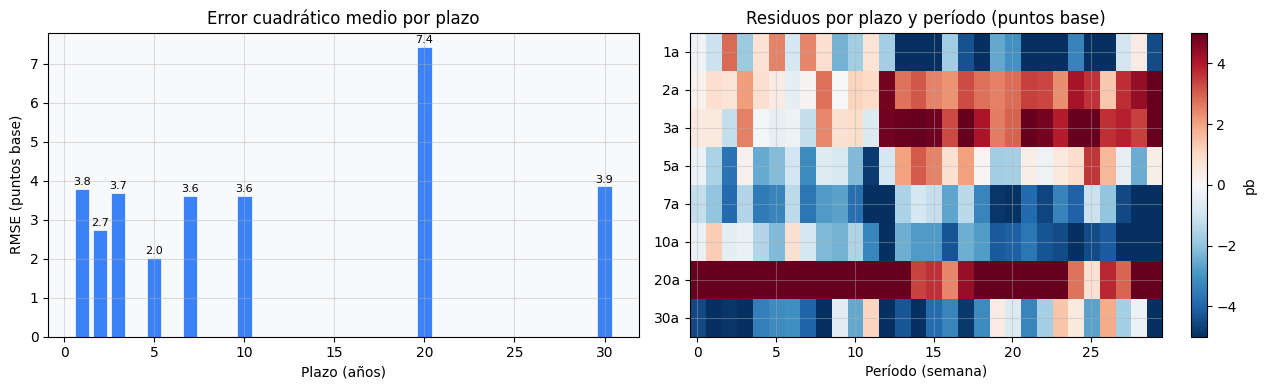

RMSE total del modelo: 4.113 puntos base


In [165]:
# ─── Error de ajuste: RMSE por plazo ─────────────────────────────────────────
errores = Y - Y_estimado                               # residuos totales
rmse_por_plazo = np.sqrt((errores**2).mean(axis=0))    # RMSE para cada plazo

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# RMSE por plazo
ax1 = axes[0]
bars = ax1.bar(plazos, rmse_por_plazo * 100, color='#3b82f6', edgecolor='white', linewidth=0.5)
ax1.set_xlabel('Plazo (años)')
ax1.set_ylabel('RMSE (puntos base)')
ax1.set_title('Error cuadrático medio por plazo')
for bar, val in zip(bars, rmse_por_plazo * 100):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val:.1f}', ha='center', va='bottom', fontsize=8)

# Mapa de calor de los residuos
ax2 = axes[1]
im = ax2.imshow(errores.T * 100, aspect='auto', cmap='RdBu_r', vmin=-5, vmax=5)
ax2.set_yticks(range(n_obs))
ax2.set_yticklabels([f'{t}a' for t in plazos])
ax2.set_xlabel('Período (semana)')
ax2.set_title('Residuos por plazo y período (puntos base)')
plt.colorbar(im, ax=ax2, label='pb')

plt.tight_layout()
plt.show()

rmse_total = np.sqrt((errores**2).mean()) * 100
print(f'RMSE total del modelo: {rmse_total:.3f} puntos base')

---

## Parte 9 — La ganancia de Kalman explicada

La **ganancia de Kalman** K nos dice **cuánto corrijo mi estimación** cuando llega un nuevo dato.

- K ≈ 1 → me fío totalmente de los datos nuevos, ignoro lo que predije
- K ≈ 0 → me fío de mi predicción, ignoro los datos nuevos
- K intermedia → promedio entre predicción y datos

K depende de la relación entre Q (incertidumbre del proceso) y R (incertidumbre de medición).

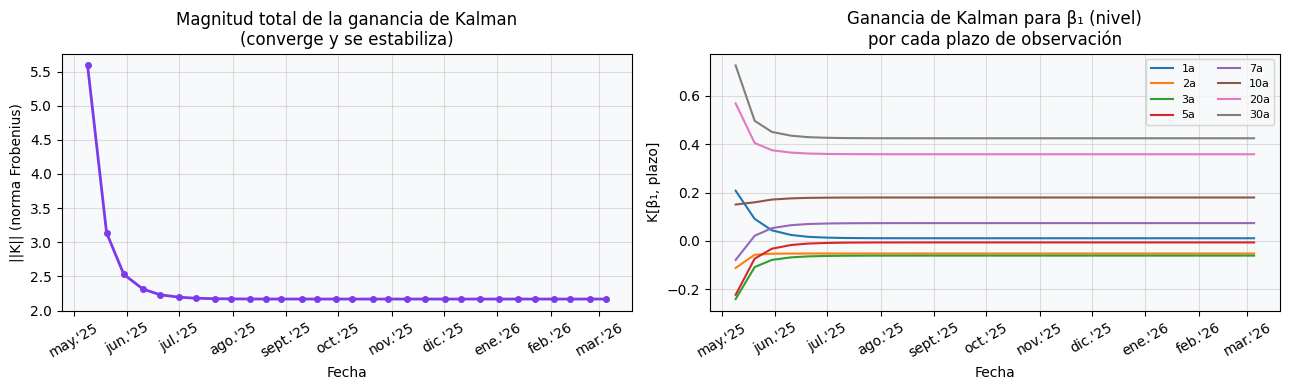

Observación: La ganancia converge rápidamente al principio
y luego se estabiliza. Esto indica que el filtro encontró
el balance óptimo entre datos y predicción.


In [166]:
# ─── Evolución de la ganancia de Kalman ─────────────────────────────────────

# Extraemos la norma de K en cada período
normas_K = np.array([np.linalg.norm(ganancias_K[k]) for k in range(T)])

# También graficamos las entradas de K para el factor β₁
K_nivel = np.array([ganancias_K[k][0, :] for k in range(T)])  # 1a fila de K

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Norma total de K
ax1 = axes[0]
ax1.plot(fechas, normas_K, '-o', color='#7c3aed', linewidth=2, markersize=4)
ax1.set_xlabel('Fecha')
ax1.set_ylabel('||K|| (norma Frobenius)')
ax1.set_title('Magnitud total de la ganancia de Kalman\n(converge y se estabiliza)')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b\'%y'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30)

# Ganancia para β₁ (nivel) por cada plazo de observación
ax2 = axes[1]
etiq_plazos = [f'{t}a' for t in plazos]
for j in range(n_obs):
    ax2.plot(fechas, K_nivel[:, j], linewidth=1.5, label=etiq_plazos[j])
ax2.set_xlabel('Fecha')
ax2.set_ylabel('K[β₁, plazo]')
ax2.set_title('Ganancia de Kalman para β₁ (nivel)\npor cada plazo de observación')
ax2.legend(ncol=2, fontsize=8)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b\'%y'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.show()

print('Observación: La ganancia converge rápidamente al principio')
print('y luego se estabiliza. Esto indica que el filtro encontró')
print('el balance óptimo entre datos y predicción.')

---

## Parte 10 — Descomposición de la curva en sus 3 factores

Mostramos cuánto contribuye cada factor (β₁·carga, β₂·carga, β₃·carga) a la curva total en el último período observado.

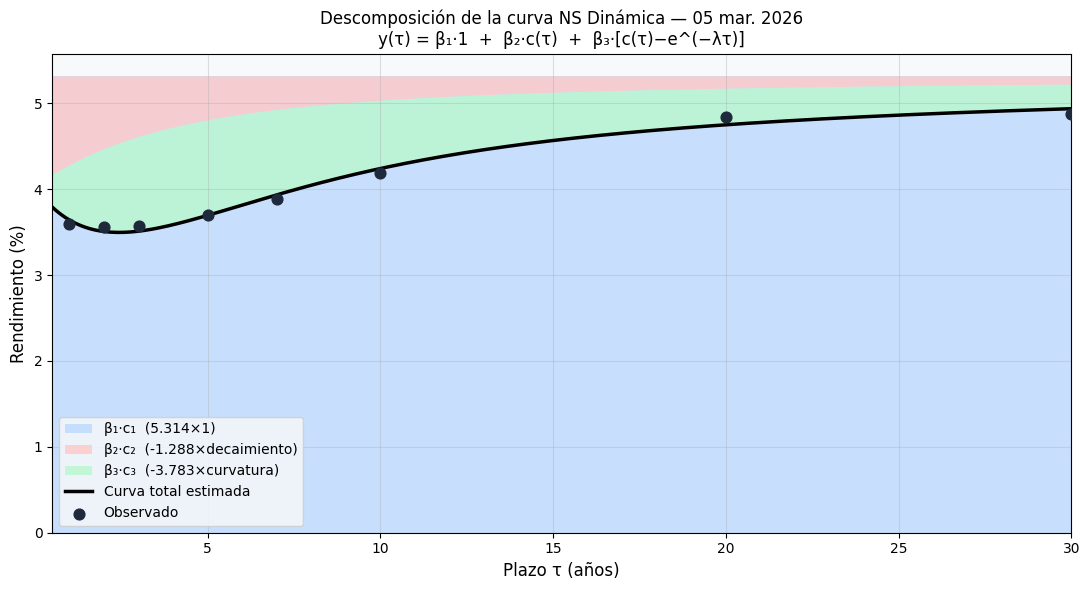

In [167]:
tau_fino = np.linspace(0.5, 30, 300)
C_fino   = matriz_carga_C(tau_fino, lam)

# Tomamos el último período
idx_final = T - 1
beta      = X_filtrado[idx_final]
fecha_fin = df.index[idx_final].strftime('%d %b %Y')

# Contribución de cada factor
contrib_nivel     = beta[0] * C_fino[:, 0]   # β₁ × carga_nivel
contrib_pendiente = beta[1] * C_fino[:, 1]   # β₂ × carga_pendiente
contrib_curvatura = beta[2] * C_fino[:, 2]   # β₃ × carga_curvatura
curva_total       = contrib_nivel + contrib_pendiente + contrib_curvatura

fig, ax = plt.subplots(figsize=(11, 6))

# Áreas apiladas
ax.stackplot(tau_fino,
             contrib_nivel, contrib_pendiente, contrib_curvatura,
             labels=[f'β₁·c₁  ({beta[0]:.3f}×1)',
                     f'β₂·c₂  ({beta[1]:.3f}×decaimiento)',
                     f'β₃·c₃  ({beta[2]:.3f}×curvatura)'],
             colors=['#bfdbfe', '#fecaca', '#bbf7d0'],
             alpha=0.85)

# Curva total
ax.plot(tau_fino, curva_total, 'k-', linewidth=2.5, label='Curva total estimada')

# Puntos observados
ax.scatter(plazos, Y[idx_final], color='#1e293b', s=60, zorder=5, label='Observado')

ax.set_xlabel('Plazo τ (años)', fontsize=12)
ax.set_ylabel('Rendimiento (%)', fontsize=12)
ax.set_title(f'Descomposición de la curva NS Dinámica — {fecha_fin}\n'
             f'y(τ) = β₁·1  +  β₂·c(τ)  +  β₃·[c(τ)−e^(−λτ)]', fontsize=12)
ax.legend(fontsize=10)
ax.set_xlim(0.5, 30)

plt.tight_layout()
plt.show()

---

## Parte 11 — Resumen completo y conclusiones

### Lo que hicimos

1. **Cargamos** rendimientos de Tesoros de EE.UU. a 8 plazos durante ~30 semanas
2. **Definimos** el modelo Nelson-Siegel con 3 factores: nivel, pendiente y curvatura
3. **Construimos** la matriz de cargas C que conecta factores con rendimientos
4. **Formulamos** el espacio de estados con A (transición), Q (ruido proceso), R (ruido medición)
5. **Implementamos** el Filtro de Kalman desde cero con numpy
6. **Extrajimos** los factores ocultos β₁, β₂, β₃ semana a semana
7. **Validamos** el ajuste y analizamos los residuos

### Interpretación económica de los factores

| Factor | Valor promedio | Interpretación |
|--------|---------------|----------------|
| β₁ (nivel) | ~5% | Rendimiento de muy largo plazo |
| β₂ (pendiente) | negativo | Curva invertida (corto plazo alto vs. largo plazo) |
| β₃ (curvatura) | variable | Forma de la joroba intermedia |

### El rol del Filtro de Kalman

- En cada período, **predice** cómo deberían estar los factores
- Luego **corrige** esa predicción con los rendimientos observados
- La **ganancia K** pondera automáticamente cuánto fijarse en datos vs. predicción
- La **incertidumbre P** se actualiza y refleja nuestra confianza en cada momento

### Posibles extensiones

- **Kalman Suavizador (RTS Smoother)**: usa toda la muestra para refinar las estimaciones anteriores
- **Estimación de parámetros (EM algorithm)**: optimizar Q, R y λ en lugar de fijarlos
- **Modelos no lineales**: extender a filtro de Kalman extendido (EKF) o UKF

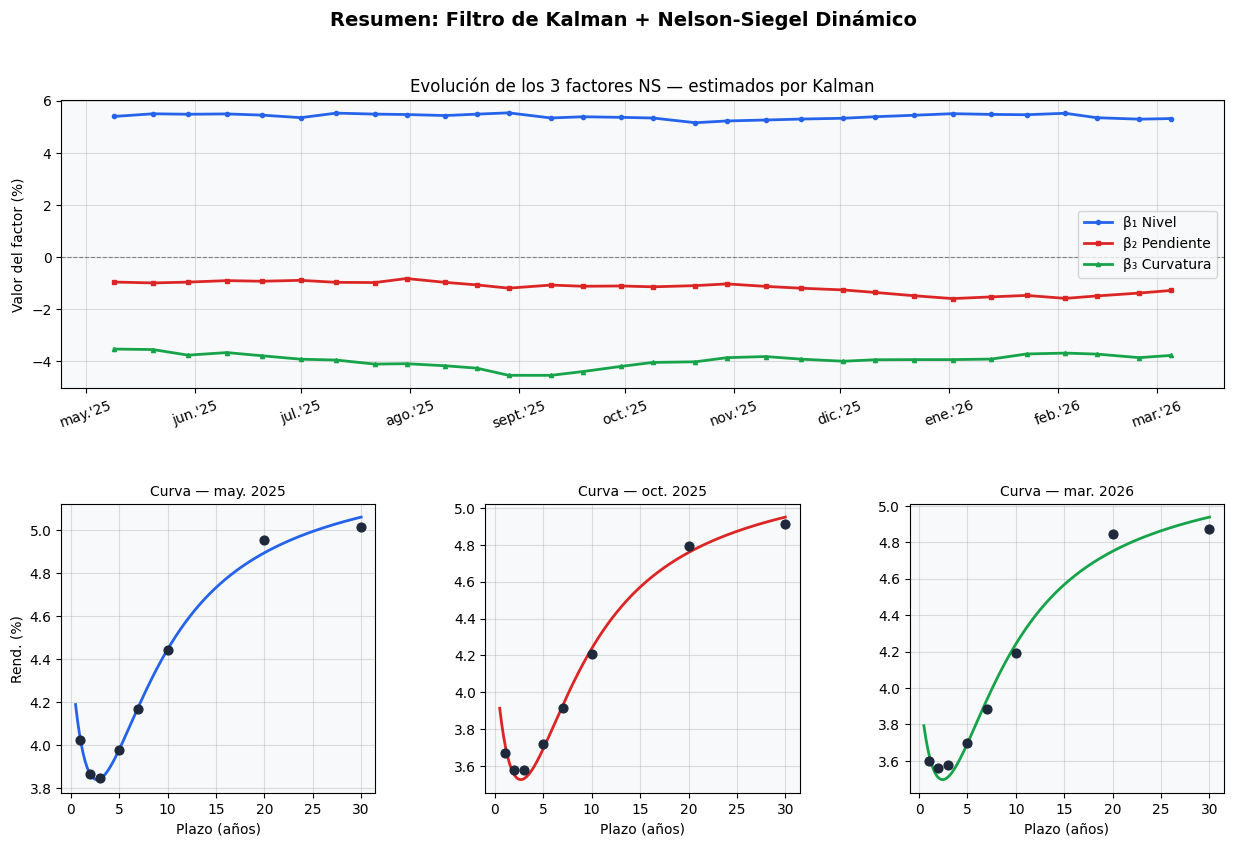


=== FIN DEL NOTEBOOK ===
RMSE total: 4.113 puntos base
Períodos analizados: 30
Plazos modelados: [np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(7), np.int64(10), np.int64(20), np.int64(30)] años


In [168]:
# ─── Panel resumen final ─────────────────────────────────────────────────────

fig = plt.figure(figsize=(15, 9))
gs  = GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# Panel 1: factores en el tiempo
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(fechas, X_filtrado[:, 0], '-o', color='#2563eb', ms=3, lw=2, label='β₁ Nivel')
ax1.plot(fechas, X_filtrado[:, 1], '-s', color='#dc2626', ms=3, lw=2, label='β₂ Pendiente')
ax1.plot(fechas, X_filtrado[:, 2], '-^', color='#16a34a', ms=3, lw=2, label='β₃ Curvatura')
ax1.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax1.set_title('Evolución de los 3 factores NS — estimados por Kalman', fontsize=12)
ax1.set_ylabel('Valor del factor (%)')
ax1.legend()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b\'%y'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=20)

# Panel 2: primer período
ax2 = fig.add_subplot(gs[1, 0])
y_est_fino = C_fino @ X_filtrado[0]
ax2.scatter(plazos, Y[0], color='#1e293b', s=40, zorder=5)
ax2.plot(tau_fino, y_est_fino, color='#2563eb', lw=2)
ax2.set_title(f'Curva — {df.index[0].strftime("%b %Y")}', fontsize=10)
ax2.set_xlabel('Plazo (años)'); ax2.set_ylabel('Rend. (%)')

# Panel 3: período medio
ax3 = fig.add_subplot(gs[1, 1])
mid = T // 2
y_est_fino = C_fino @ X_filtrado[mid]
ax3.scatter(plazos, Y[mid], color='#1e293b', s=40, zorder=5)
ax3.plot(tau_fino, y_est_fino, color='#dc2626', lw=2)
ax3.set_title(f'Curva — {df.index[mid].strftime("%b %Y")}', fontsize=10)
ax3.set_xlabel('Plazo (años)')

# Panel 4: último período
ax4 = fig.add_subplot(gs[1, 2])
y_est_fino = C_fino @ X_filtrado[-1]
ax4.scatter(plazos, Y[-1], color='#1e293b', s=40, zorder=5)
ax4.plot(tau_fino, y_est_fino, color='#16a34a', lw=2)
ax4.set_title(f'Curva — {df.index[-1].strftime("%b %Y")}', fontsize=10)
ax4.set_xlabel('Plazo (años)')

fig.suptitle('Resumen: Filtro de Kalman + Nelson-Siegel Dinámico', fontsize=14, fontweight='bold')
plt.show()

print('\n=== FIN DEL NOTEBOOK ===')
print(f'RMSE total: {rmse_total:.3f} puntos base')
print(f'Períodos analizados: {T}')
print(f'Plazos modelados: {list(plazos)} años')